In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np, matplotlib.pyplot as plt
from jax import random

from Style     import useAA         
from Tensorize import loadDataset
from NSF       import makeModels, train, checkTransition
from GapFill   import fillGaps, drwGPBaseline, gapWidths, coverage, plotGapFill, evalCurve

useAA()
DATA = "/Users/anacecilialr/GitHub/MASS/MASS-Thesis/data/VaryTau/"

## Lambda experiments
### 1. Load

In [2]:
D = loadDataset(f"{DATA}/train.npz")
V = loadDataset(f"{DATA}/val.npz", t_scale=D["t_scale"], y_scale=D["y_scale"])   # SAME scales

# all the curves no longer share the same tau and sigma
tau_n_all = np.asarray(D["tau"])
print(f"train {D['t'].shape}   val {V['t'].shape}")
print(f"tau_n: {tau_n_all.min():.3f}-{tau_n_all.max():.3f} across curves "
      f"(median {np.median(tau_n_all):.3f})")
# prints sigma normalized
print(f"sigma_n = {float(D['sigma'][0]):.2f},  max|y| = {float(abs(D['y'][D['mask']]).max()):.2f},  max t = {float(D['t'].max()):.2f}")

train (2400, 108)   val (600, 101)
tau_n: 0.062-0.405 across curves (median 0.152)
sigma_n = 1.00,  max|y| = 5.18,  max t = 1.00


### 2. Train (to test)

Total loss (Kiyohara Eq. 11):
$$\mathcal{L}(\theta,\xi) = \underbrace{-\mathbb{E}_{\mathcal{D}}\left[\log p_\theta(x_{t_j}\mid x_{t_i})\right]}_{\mathcal{L}_{\rm NLL}} + \lambda\,\mathcal{L}_{\rm flow}(\theta,\xi)$$

Without **$\mathcal{L}_{\rm NLL}$** the model is trained only to be *self-consistent*, a property infinitely many wrong dynamics satisfy, and it never learns the DRW at all. Gap filling would still look plausible, because the bridge is conditioned on real endpoints at inference

`lam = 0.1`: Kiyohara use 0.4 (Lorenz), find ~0.03 best (mocap), and report that
sub-order-of-magnitude values suffice.

  step   100 | loss   1.5381
  step   200 | loss   1.0838
  step   300 | loss   1.0718
  step   400 | loss   1.0733
  step   500 | loss   1.0651
  step   600 | loss   1.0593

final loss 1.070   <- ~1-2 is healthy; ~50 means unnormalised data


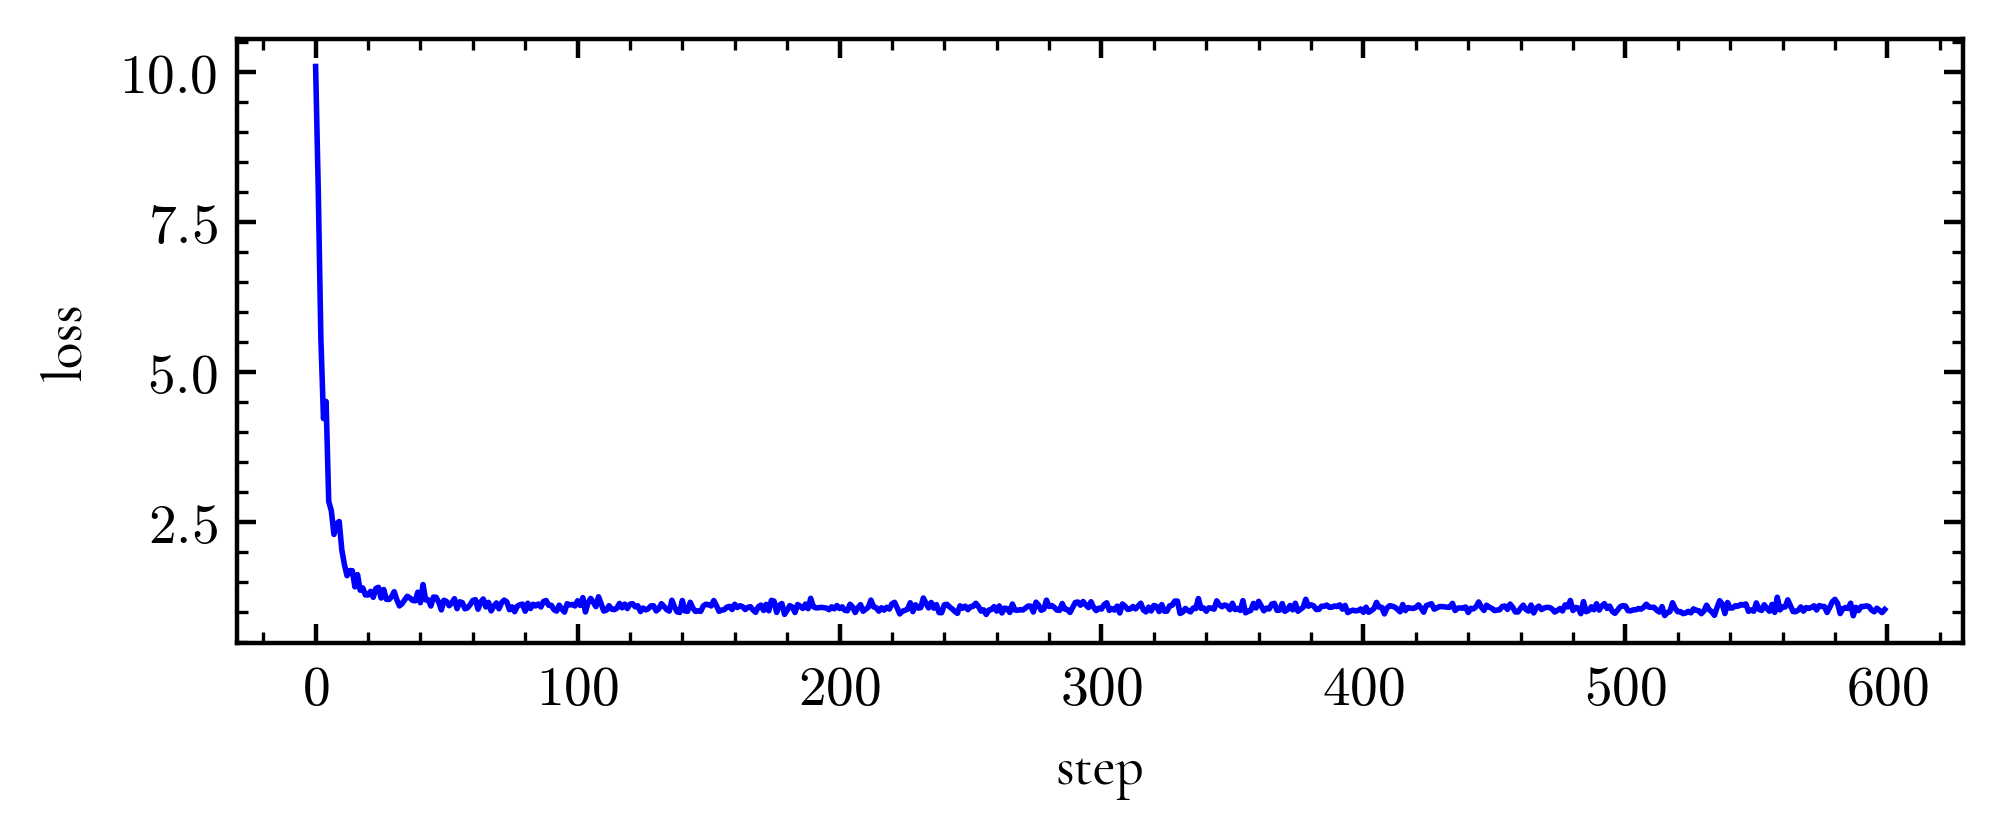

In [3]:
flow, bridge = makeModels(random.PRNGKey(0))
(flow, bridge), hist = train(flow, bridge, D, random.PRNGKey(1),
                             steps=600, batch=16, lr=2e-3, lam=0.1, n_trip=32)

print(f"\nfinal loss {np.mean(hist[-50:]):.3f}   <- ~1-2 is healthy; ~50 means unnormalised data")
plt.figure(figsize=(5, 2.2))
plt.plot(hist, lw=1, color="blue")
plt.xlabel("step"); plt.ylabel("loss")
plt.tight_layout()
plt.savefig("/Users/anacecilialr/GitHub/MASS/MASS-Thesis/assets/5_figures/VaryTauExp/Loss.pdf")
#plt.savefig("/Users/anacecilialr/GitHub/MASS/MASS-Thesis/assets/5_figures/FixedTauExp/Loss.pdf")
plt.show()

### 3, Vary lambda

In [5]:
lambdas = [0.03, 0.1, 0.3, 1.0]     # log-spaced around 0.1
sweep = {}
for lam in lambdas:
    flow, bridge = makeModels(random.PRNGKey(0))          # SAME init every time
    (flow, bridge), hist = train(flow, bridge, D, random.PRNGKey(1),
                                 steps=400, lam=lam, n_trip=32)
    res = [evalCurve(bridge, D, V, i, n_samples=100, grid_per_gap=8, seed=i)
           for i in range(60)]                            # subset for speed
    cov = np.median([x["nsf_cov"]  for x in res])
    rms = np.median([x["nsf_rmse"] for x in res])
    gap = np.median([x["nsf_rmse"] - x["gp_rmse"] for x in res])
    sweep[lam] = (cov, rms, gap, hist[-1])
    print(f"lambda={lam:5.2f}  cov {cov:.2f}  rmse {rms:.3f}  above-opt {100*gap/rms:+.0f}%  loss {hist[-1]:.2f}")

  step   100 | loss   1.5294
  step   200 | loss   1.0802
  step   300 | loss   1.0698
  step   400 | loss   1.0719
lambda= 0.03  cov 0.62  rmse 0.183  above-opt +3%  loss 1.05
  step   100 | loss   1.5381
  step   200 | loss   1.0838
  step   300 | loss   1.0718
  step   400 | loss   1.0733
lambda= 0.10  cov 0.62  rmse 0.183  above-opt +3%  loss 1.05
  step   100 | loss   1.5663
  step   200 | loss   1.0938
  step   300 | loss   1.0767
  step   400 | loss   1.0767
lambda= 0.30  cov 0.62  rmse 0.182  above-opt +3%  loss 1.05
  step   100 | loss   1.6555
  step   200 | loss   1.1198
  step   300 | loss   1.0904
  step   400 | loss   1.0861
lambda= 1.00  cov 0.60  rmse 0.182  above-opt +3%  loss 1.06


In [6]:
lambdas = [0.07, 0.2, 0.5, 0.7, 0.85, 0.9, 0.95]     # log-spaced around 0.1
sweep = {}
for lam in lambdas:
    flow, bridge = makeModels(random.PRNGKey(0))          # SAME init every time
    (flow, bridge), hist = train(flow, bridge, D, random.PRNGKey(1),
                                 steps=400, lam=lam, n_trip=32)
    res = [evalCurve(bridge, D, V, i, n_samples=100, grid_per_gap=8, seed=i)
           for i in range(60)]                            # subset for speed
    cov = np.median([x["nsf_cov"]  for x in res])
    rms = np.median([x["nsf_rmse"] for x in res])
    gap = np.median([x["nsf_rmse"] - x["gp_rmse"] for x in res])
    sweep[lam] = (cov, rms, gap, hist[-1])
    print(f"lambda={lam:5.2f}  cov {cov:.2f}  rmse {rms:.3f}  above-opt {100*gap/rms:+.0f}%  loss {hist[-1]:.2f}")

  step   100 | loss   1.5341
  step   200 | loss   1.0822
  step   300 | loss   1.0710
  step   400 | loss   1.0727
lambda= 0.07  cov 0.62  rmse 0.183  above-opt +3%  loss 1.05
  step   100 | loss   1.5522
  step   200 | loss   1.0889
  step   300 | loss   1.0744
  step   400 | loss   1.0751
lambda= 0.20  cov 0.62  rmse 0.183  above-opt +3%  loss 1.05
  step   100 | loss   1.5937
  step   200 | loss   1.1026
  step   300 | loss   1.0811
  step   400 | loss   1.0796
lambda= 0.50  cov 0.61  rmse 0.182  above-opt +3%  loss 1.06
  step   100 | loss   1.6194
  step   200 | loss   1.1102
  step   300 | loss   1.0851
  step   400 | loss   1.0822
lambda= 0.70  cov 0.61  rmse 0.182  above-opt +3%  loss 1.06
  step   100 | loss   1.6378
  step   200 | loss   1.1152
  step   300 | loss   1.0878
  step   400 | loss   1.0842
lambda= 0.85  cov 0.60  rmse 0.182  above-opt +3%  loss 1.06
  step   100 | loss   1.6437
  step   200 | loss   1.1168
  step   300 | loss   1.0887
  step   400 | loss   1.0848

In [ ]:
lam = list(sweep); cov = [sweep[l][0] for l in lam]; rms = [sweep[l][1] for l in lam]
fig, ax1 = plt.subplots(figsize=(5,3.2))
ax1.axhline(0.68, color="0.7", lw=.8, ls="--")                 # the calibration target
ax1.plot(lam, cov, "o-", color="steelblue", label="coverage")
ax1.set_xscale("log"); ax1.set_xlabel(r"$\lambda$"); ax1.set_ylabel("coverage@68%", color="steelblue")
ax2 = ax1.twinx()
ax2.plot(lam, rms, "s-", color="indianred", label="RMSE")
ax2.set_ylabel("RMSE", color="indianred")
plt.tight_layout(); plt.show()